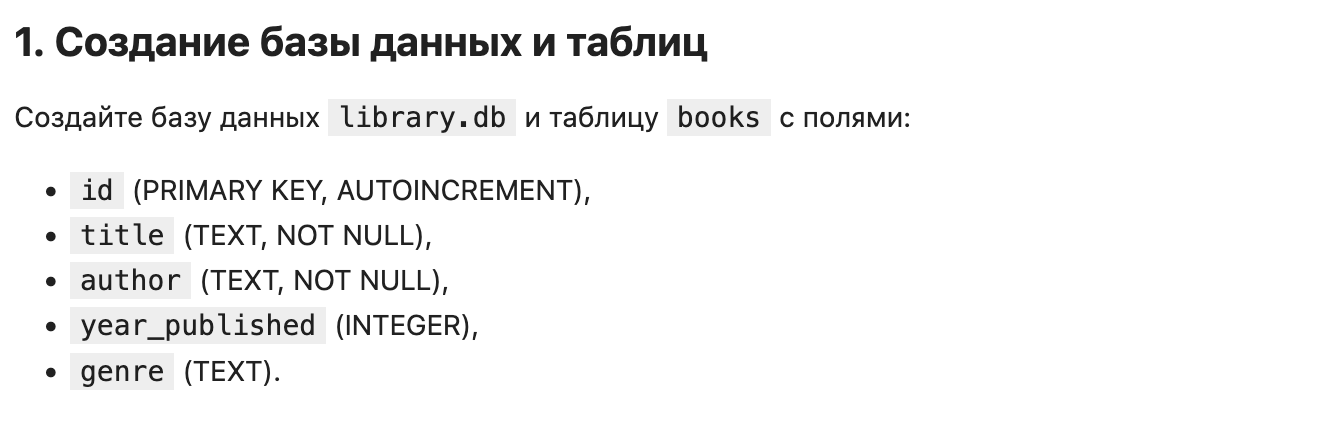

In [4]:
import sqlite3 as sql
import pandas as pd 
con=sql.connect("library.db")
cursor=con.cursor()
query="""
CREATE TABLE IF NOT EXISTS books(
id INTEGER PRIMARY KEY AUTOINCREMENT,
title TEXT NOT NULL,
author TEXT NOT NULL,
year_published INTEGER,
genre TEXT

)
"""
cursor.execute(query)
con.commit()


In [3]:
cursor.execute("DROP TABLE IF EXISTS books")

con.commit()
cursor.execute("DROP TABLE IF EXISTS books_logs")

con.commit()

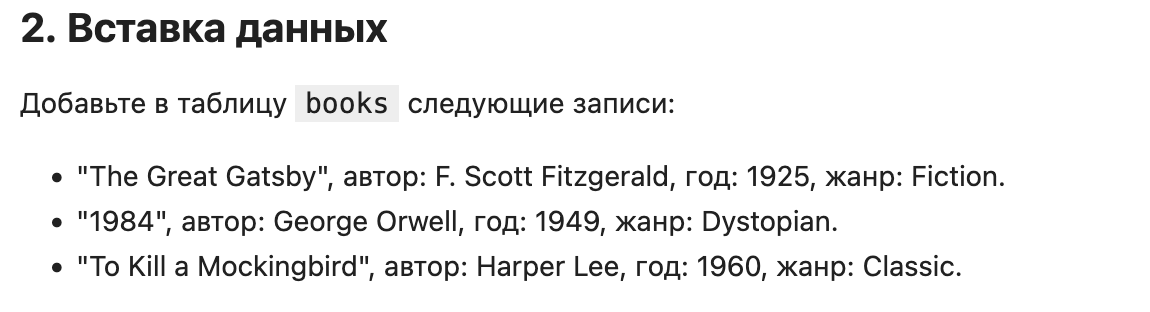

In [5]:
query="""
INSERT INTO books (title,author,year_published,genre)
VALUES(?,?,?,?)
"""
book1=("The great Gatsby","F. Scott Fitzgerald",1925,"Firction")
book2=("1984","George Orwell",1949,"Dystopian")
book3=("To Kill a Mockingbird","Harper Lee",1960,"Classic")
cursor.execute(query,book1)

cursor.execute(query,book2)

cursor.execute(query,book3)
con.commit()

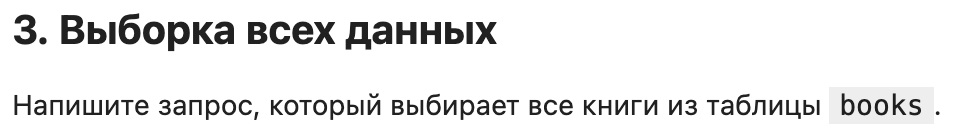

In [6]:

query="""
SELECT * FROM books
"""
db=pd.read_sql(query,con)
db

,id,title,author,year_published,genre
0,1,The great Gatsby,F. Scott Fitzgerald,1925,Firction
1,2,1984,George Orwell,1949,Dystopian
2,3,To Kill a Mockingbird,Harper Lee,1960,Classic


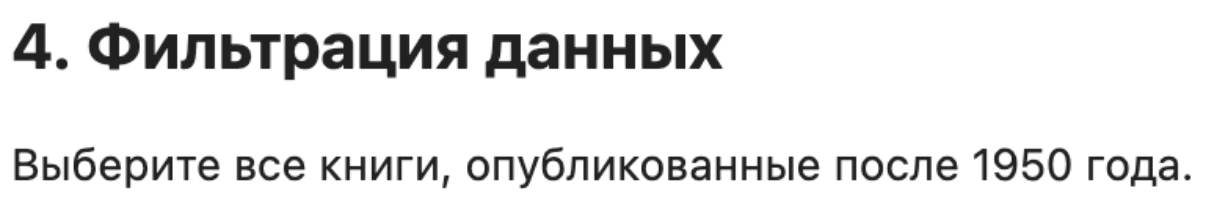

In [7]:
query="""
SELECT * FROM books 
WHERE year_published > 1950
"""
db=pd.read_sql(query,con)
db

,id,title,author,year_published,genre
0,3,To Kill a Mockingbird,Harper Lee,1960,Classic


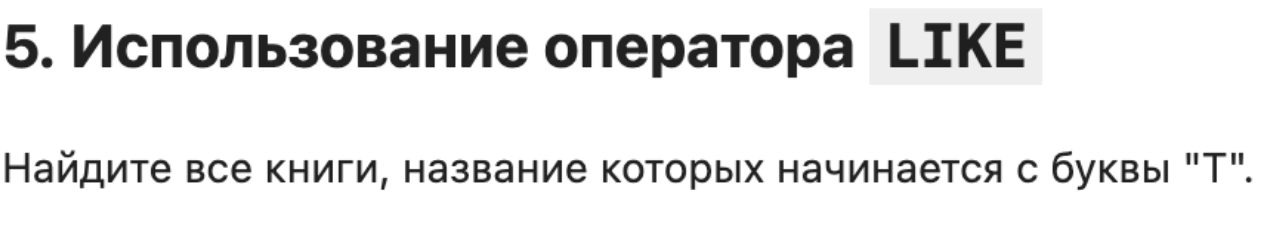

In [8]:
query="""
SELECT * FROM books 
WHERE title like "T%"
"""
db=pd.read_sql(query,con)
db

,id,title,author,year_published,genre
0,1,The great Gatsby,F. Scott Fitzgerald,1925,Firction
1,3,To Kill a Mockingbird,Harper Lee,1960,Classic


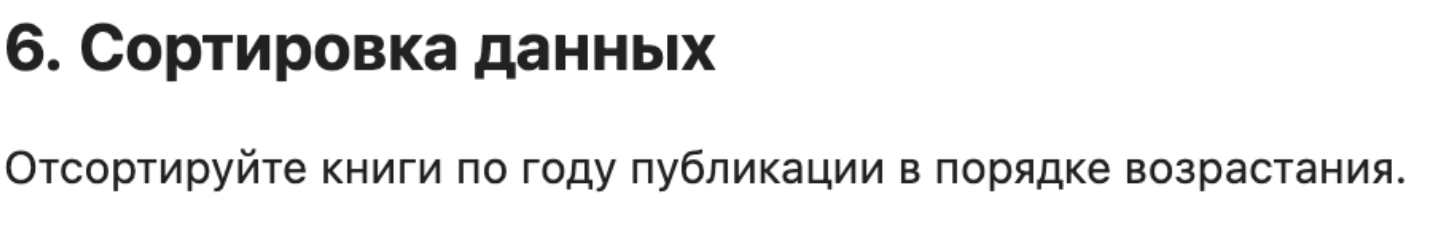

In [9]:
query="""
SELECT * FROM books 
ORDER BY year_published ASC
"""
db=pd.read_sql(query,con)
db

,id,title,author,year_published,genre
0,1,The great Gatsby,F. Scott Fitzgerald,1925,Firction
1,2,1984,George Orwell,1949,Dystopian
2,3,To Kill a Mockingbird,Harper Lee,1960,Classic


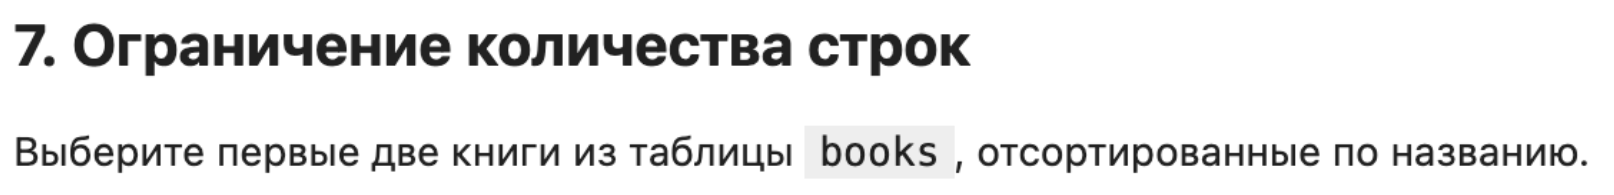

In [10]:
query="""
SELECT * FROM books 
ORDER BY title ASC
LIMIT 2
"""
db=pd.read_sql(query,con)
db

,id,title,author,year_published,genre
0,2,1984,George Orwell,1949,Dystopian
1,1,The great Gatsby,F. Scott Fitzgerald,1925,Firction


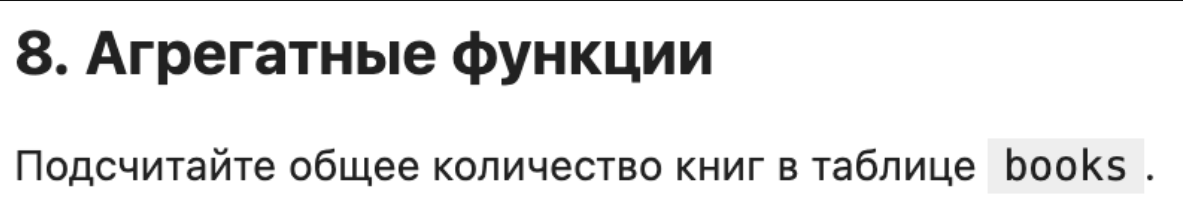|

In [11]:
query="""
SELECT COUNT(title) as 'Количество'
FROM books 
"""
db=pd.read_sql(query,con)
db

,Количество
0,3


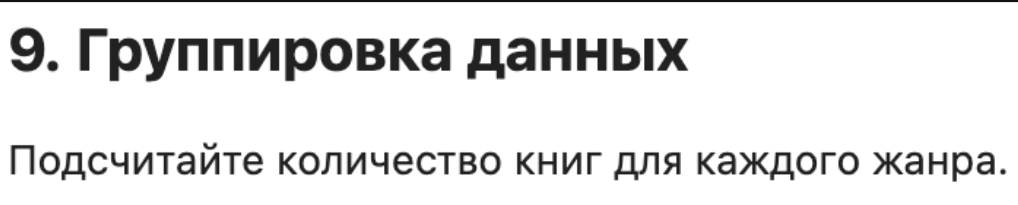

In [12]:
query="""
SELECT genre, COUNT(*) as count
FROM books 
GROUP BY GENRE
"""
db=pd.read_sql(query,con)
db

,genre,count
0,Classic,1
1,Dystopian,1
2,Firction,1


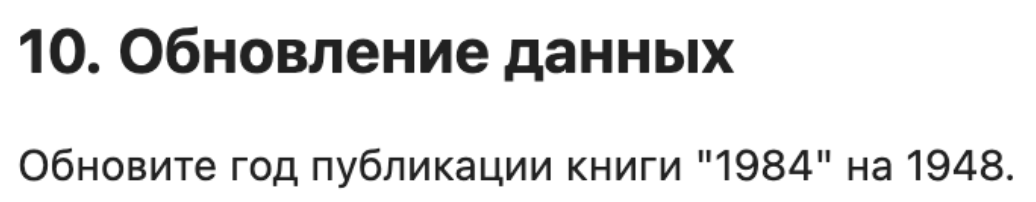

In [13]:
cursor.execute("""
UPDATE books
SET year_published = 1984
WHERE title = "1984"
""")

con.commit()


In [14]:
query = """
SELECT *
FROM books
"""

db = pd.read_sql(query, con)
db

,id,title,author,year_published,genre
0,1,The great Gatsby,F. Scott Fitzgerald,1925,Firction
1,2,1984,George Orwell,1984,Dystopian
2,3,To Kill a Mockingbird,Harper Lee,1960,Classic


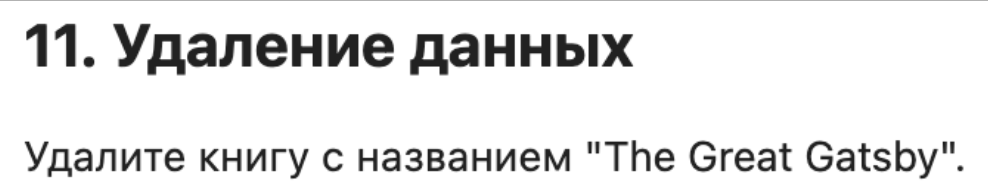

In [15]:
cursor.execute("""
DELETE FROM books
WHERE title = "The great Gatsby"
""")

con.commit()

In [16]:
query = """
SELECT *
FROM books
"""

db = pd.read_sql(query, con)
db

,id,title,author,year_published,genre
0,2,1984,George Orwell,1984,Dystopian
1,3,To Kill a Mockingbird,Harper Lee,1960,Classic


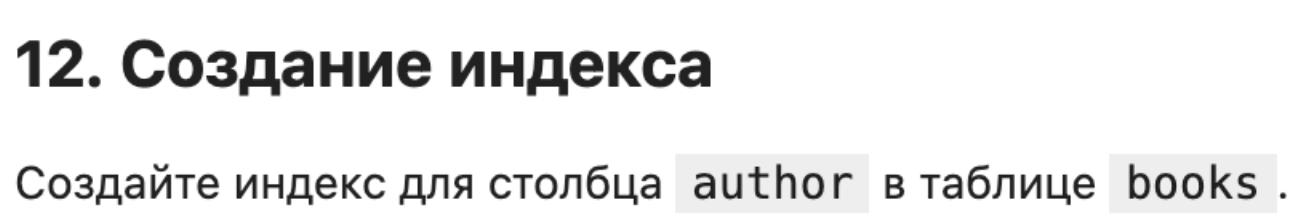

In [17]:
cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_books_author
ON books (author);
""")

con.commit()

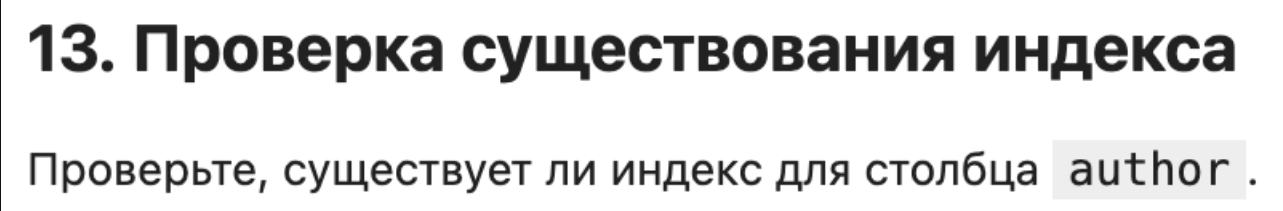

In [18]:
query = """
SELECT name
FROM sqlite_master
WHERE type='index' AND name='idx_books_author'
"""

db = pd.read_sql(query, con)
db

,name
0,idx_books_author


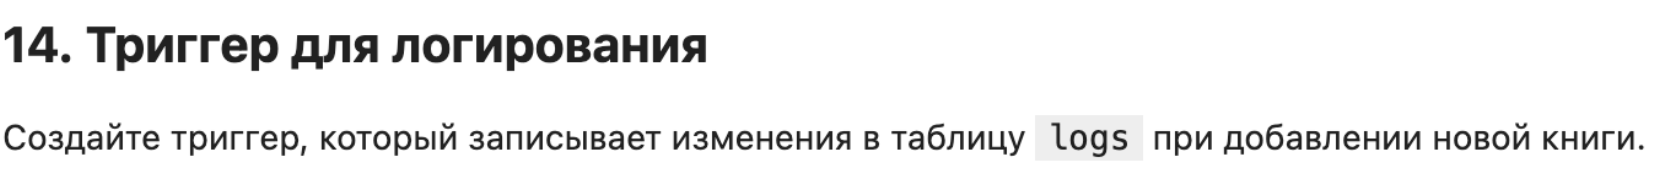

In [19]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS books_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    book_id INTEGER,
    action TEXT,
    timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
);
''')

cursor.execute('''
CREATE TRIGGER IF NOT EXISTS log_books_changes
AFTER INSERT ON books
FOR EACH ROW
BEGIN
    INSERT INTO books_logs (book_id, action)
    VALUES (NEW.id, 'INSERT');
END;
''')


cursor.execute("""
INSERT INTO books (title, author, year_published, genre)
VALUES (?, ?, ?, ?);
""", ("The Great Gatsby", "F. Scott Fitzgerald", 1925, "Fiction"))

query = """
SELECT *
FROM books_logs
"""

db = pd.read_sql(query, con)
db

,id,book_id,action,timestamp
0,1,4,INSERT,2025-04-25 13:55:02


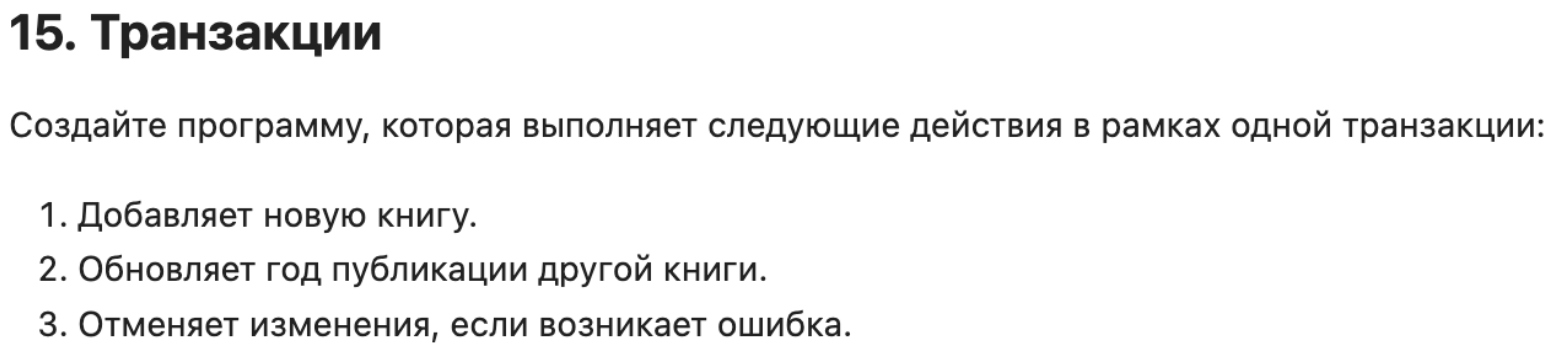

In [26]:
def perform_book_transaction():
    conn = None
    try:
        # Начинаем транзакцию
        con.execute("BEGIN TRANSACTION")
        
        # 1. Добавляем новую книгу
        new_book = ("Brave New World", "Aldous Huxley", 1932, "Dystopian")
        cursor.execute("""
            INSERT INTO books (title, author, year_published, genre)
            VALUES (?, ?, ?, ?)
        """, new_book)
        print("Добавлена новая книга:", new_book[0])
        
        # 2. Обновляем год публикации другой книги
        update_book = (1951, "1984")  # Новый год для книги "1984"
        cursor.execute("""
            UPDATE books 
            SET year_published = ? 
            WHERE title = ?
        """, update_book)
        print(f"Обновлен год публикации книги '{update_book[1]}' на {update_book[0]}")
        
        conn.commit()
        print("Транзакция успешно завершена!")
        
    except sql.Error as e:
        if conn:
            conn.rollback()
        print(f"Ошибка: {e}. Все изменения отменены.")
        
# Вызываем функцию для выполнения транзакции
perform_book_transaction()

Ошибка: cannot start a transaction within a transaction. Все изменения отменены.


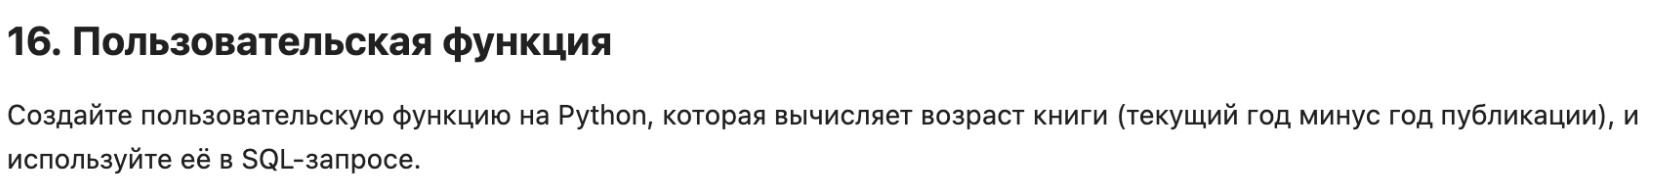

In [28]:
from datetime import datetime

def calc_book_age(year_published):
    current_year = datetime.now().year
    return current_year - year_published

con.create_function('book_age', 1, calc_book_age)

cursor = con.cursor()

cursor.execute('''
SELECT title, year_published, book_age(year_published)
FROM books
''')
books_with_age = cursor.fetchall()

for book in books_with_age:
    print(f"{book[0]} ({book[1]}): {book[2]} лет")

1984 (1984): 41 лет
To Kill a Mockingbird (1960): 65 лет
The Great Gatsby (1925): 100 лет


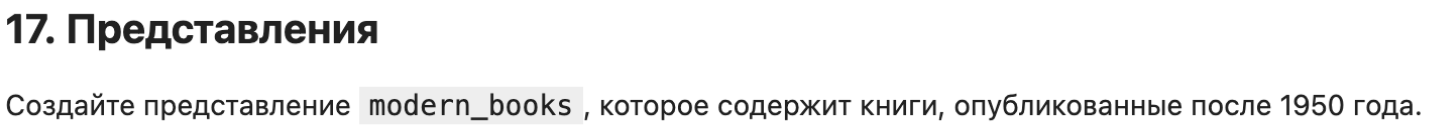

In [31]:
cursor.execute('''
CREATE VIEW IF NOT EXISTS modern_books AS
SELECT * FROM books WHERE year_published > 1950
''')
con.commit()


cursor.execute('SELECT * FROM modern_books')
modern_books = cursor.fetchall()
for book in modern_books:
    print(book)

con.close()

(2, '1984', 'George Orwell', 1984, 'Dystopian')
(3, 'To Kill a Mockingbird', 'Harper Lee', 1960, 'Classic')


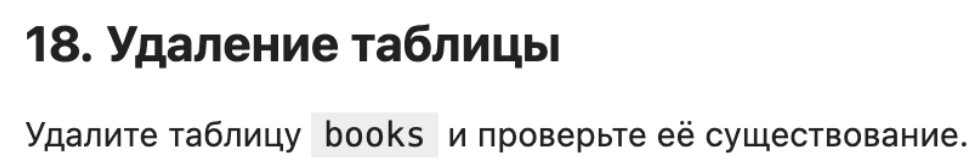

In [37]:
con = sql.connect('library.db')
cursor = con.cursor()
cursor.execute('DROP TABLE IF EXISTS books')

query = """
SELECT *
FROM books
"""

try:
  db = pd.read_sql(query, conn)
  db  
except Exception:
  print("Нет таблицы!")
con.close()

Нет таблицы!


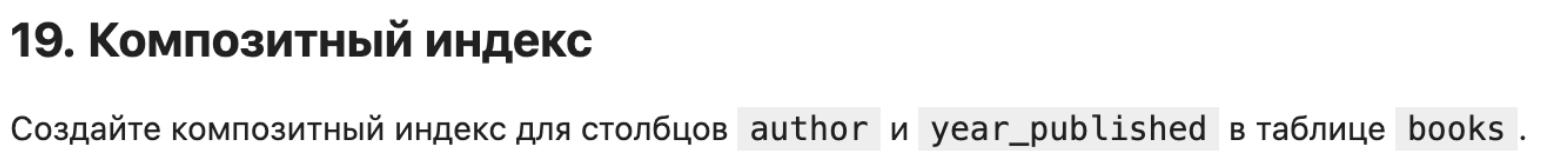

In [34]:
con = sql.connect('library.db')
cursor = con.cursor()

cursor.execute('''
CREATE INDEX IF NOT EXISTS idx_author_year
ON books (author, year_published)
''')
con.commit()
con.close()

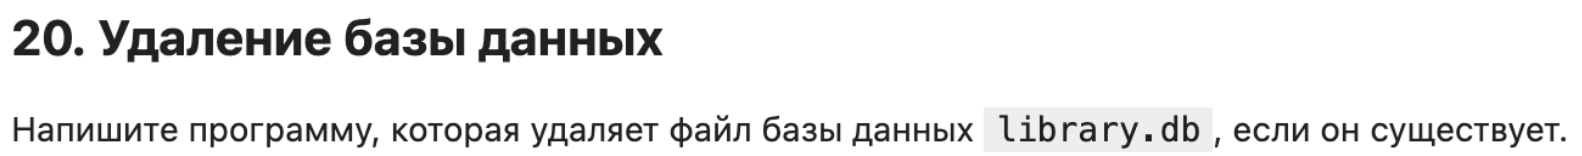

In [38]:
import os
if os.path.exists('library.db'):
    os.remove('library.db')
    print("\nФайл базы данных library.db удален")
else:
    print("\nФайл базы данных library.db не существует")


Файл базы данных library.db удален
